In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Lecture directe du fichier réel local
df_plants = pd.read_csv('C:/Users/hp/Desktop/DI_BOOTCAMP/week3/Day2/DailyChallenge/global_power_plant_database.csv', low_memory=False)

print(f"✅ Fichier importé avec succès : {len(df_plants)} centrales détectées.")


✅ Fichier importé avec succès : 34936 centrales détectées.


In [3]:
# 1. Conversion et nettoyage de la puissance (capacity_mw)
df_plants['capacity_mw'] = pd.to_numeric(df_plants['capacity_mw'], errors='coerce')
df_plants['capacity_mw'] = df_plants['capacity_mw'].fillna(0)

# 2. Gestion des valeurs manquantes de l'année (commissioning_year)
# Extraction de la médiane avec NumPy en ignorant les NaN existants
median_year = np.nanmedian(df_plants['commissioning_year'])
df_plants['commissioning_year'] = df_plants['commissioning_year'].fillna(median_year)

# 3. Suppression des coordonnées géographiques invalides
df_plants = df_plants.dropna(subset=['latitude', 'longitude'])

print("🧹 Nettoyage terminé. Aucune valeur manquante sur les colonnes clés.")


🧹 Nettoyage terminé. Aucune valeur manquante sur les colonnes clés.


In [4]:
# 1. Agrégation Pandas
print("--- DESCRIPTION DES PUISSANCES (MW) ---")
print(df_plants['capacity_mw'].describe().round(1))

# 2. Filtrage vectorisé NumPy par type de combustible
print("\n--- STATISTIQUES PAR TYPE DE CARBURANT ---")
top_fuels = df_plants['primary_fuel'].value_counts().head(5).index.tolist()

for fuel in top_fuels:
    mask = (df_plants['primary_fuel'] == fuel).to_numpy()
    capacities = df_plants.loc[mask, 'capacity_mw'].to_numpy()
    print(f"- {fuel:12} : Moyenne = {np.mean(capacities):.1f} MW | Écart-type = {np.std(capacities):.1f} MW")

# 3. Test statistique ANOVA entre les 3 plus grands groupes combustibles
groupes = [df_plants[df_plants['primary_fuel'] == f]['capacity_mw'].to_numpy() for f in top_fuels[:3]]
f_stat, p_val = stats.f_oneway(*groupes)

print("\n--- RÉSULTAT DU TEST D'HYPOTHÈSE ---")
print(f"Statistique F : {f_stat:.2f} | P-value : {p_val:.4e}")
if p_val < 0.05:
    print("👉 Rejet de H0 : Les puissances moyennes diffèrent significativement selon l'énergie utilisée.")
else:
    print("👉 Échec de rejet de H0 : Pas de différence statistiquement significative.")


--- DESCRIPTION DES PUISSANCES (MW) ---
count    34936.0
mean       163.4
std        489.6
min          1.0
25%          4.9
50%         16.7
75%         75.3
max      22500.0
Name: capacity_mw, dtype: float64

--- STATISTIQUES PAR TYPE DE CARBURANT ---
- Solar        : Moyenne = 17.7 MW | Écart-type = 41.9 MW
- Hydro        : Moyenne = 147.2 MW | Écart-type = 549.8 MW
- Wind         : Moyenne = 49.2 MW | Écart-type = 106.1 MW
- Gas          : Moyenne = 373.4 MW | Écart-type = 560.9 MW
- Coal         : Moyenne = 843.6 MW | Écart-type = 888.0 MW

--- RÉSULTAT DU TEST D'HYPOTHÈSE ---
Statistique F : 379.96 | P-value : 4.3047e-163
👉 Rejet de H0 : Les puissances moyennes diffèrent significativement selon l'énergie utilisée.


In [5]:
# Groupement par tranches de 10 ans via des calculs NumPy
df_plants['decennie'] = (df_plants['commissioning_year'] // 10) * 10

# Matrice de contingence des 5 énergies principales depuis 1970
evolution = pd.crosstab(df_plants['decennie'], df_plants['primary_fuel'])[top_fuels]
print("\n--- CONSTRUCTIONS DE CENTRALES PAR DÉCENNIE ---")
print(evolution.loc[1970:2020])



--- CONSTRUCTIONS DE CENTRALES PAR DÉCENNIE ---
primary_fuel  Solar  Hydro  Wind   Gas  Coal
decennie                                    
1970.0            0    283     1   220   176
1980.0            5    536    27   280   204
1990.0            2    371    70   491   230
2000.0         7226   3823  3972  2167   988
2010.0         3310    523  1257   564   558
2020.0          122      0    17     6     0


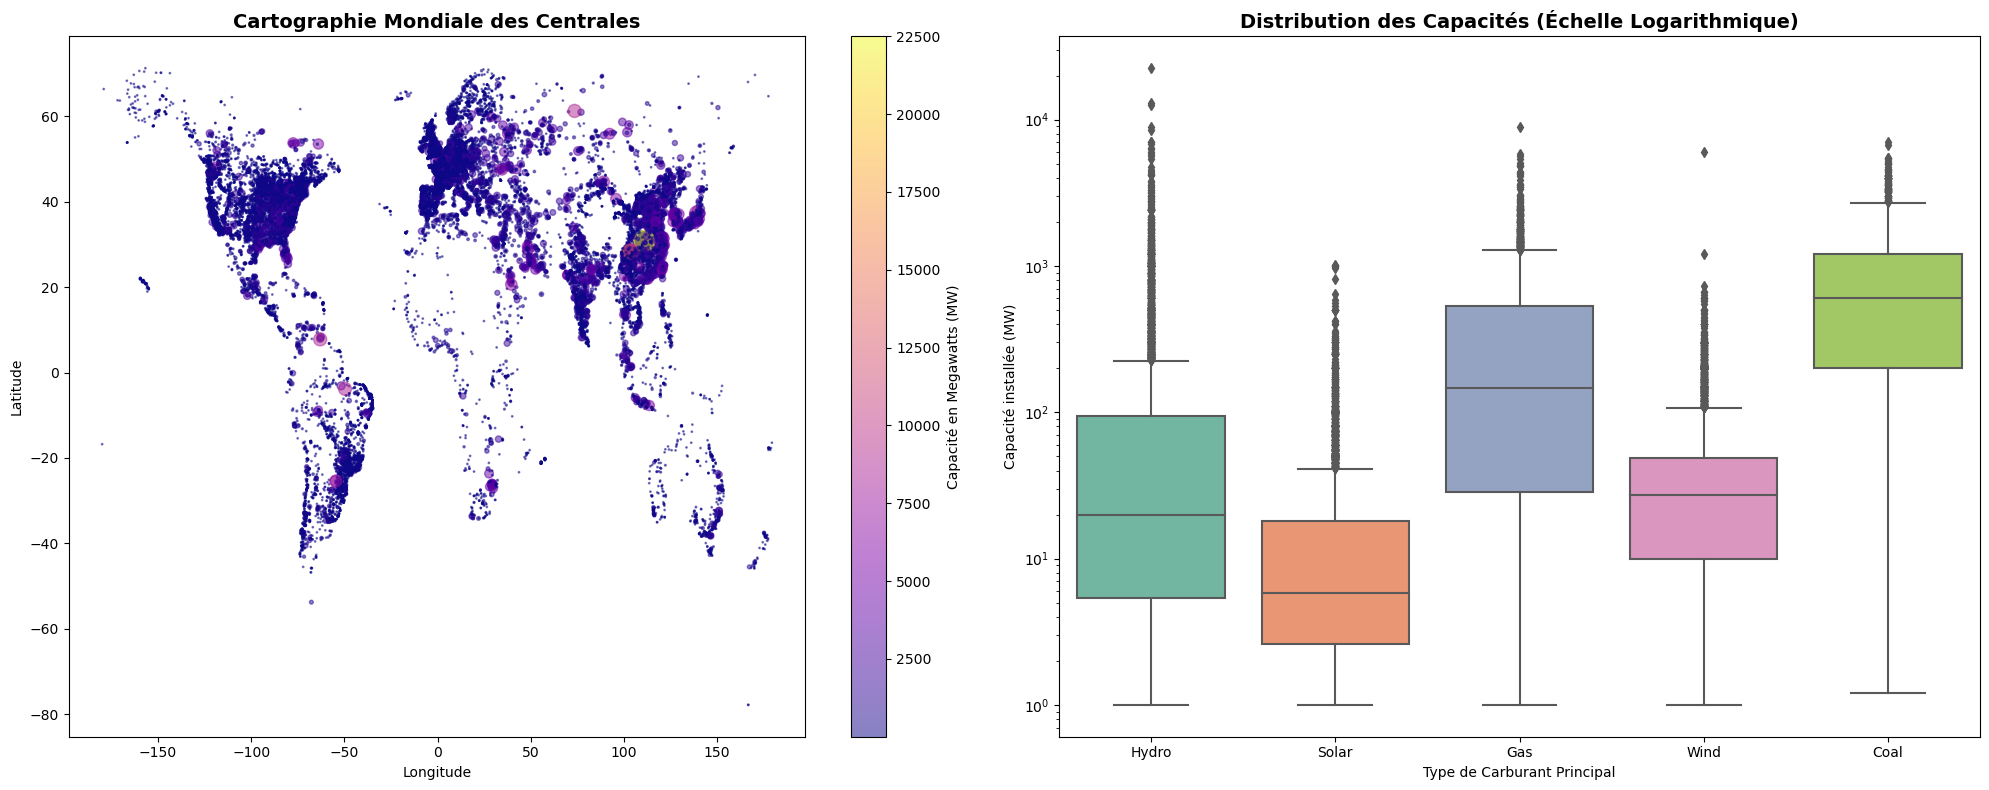

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Graphique 1 : Carte de densité des centrales mondiales
scatter = axes[0].scatter(
    df_plants['longitude'], df_plants['latitude'], 
    c=df_plants['capacity_mw'], cmap='plasma', 
    alpha=0.5, s=np.clip(df_plants['capacity_mw'] * 0.01, 1, 300)
)
axes[0].set_title("Cartographie Mondiale des Centrales", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")
fig.colorbar(scatter, ax=axes[0], label="Capacité en Megawatts (MW)")

# Graphique 2 : Boîte à moustaches des énergies majeures
df_top_fuels = df_plants[df_plants['primary_fuel'].isin(top_fuels)]
sns.boxplot(data=df_top_fuels, x='primary_fuel', y='capacity_mw', ax=axes[1], palette='Set2')
axes[1].set_yscale('log')  # Échelle logarithmique indispensable face aux disparités
axes[1].set_title("Distribution des Capacités (Échelle Logarithmique)", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Type de Carburant Principal")
axes[1].set_ylabel("Capacité installée (MW)")

plt.tight_layout()
plt.show()


In [7]:
# Extraction des attributs numériques continus
attributs = ['capacity_mw', 'commissioning_year', 'latitude', 'longitude']
matrice_np = df_plants[attributs].to_numpy()

# Génération manuelle de la matrice de corrélation via NumPy
matrice_corr = np.corrcoef(matrice_np, rowvar=False)

# Décomposition spectrale (Valeurs propres et Vecteurs propres)
valeurs_propres, vecteurs_propres = np.linalg.eig(matrice_corr)

print("--- MATRICE DE CORRÉLATION ---")
print(pd.DataFrame(matrice_corr, index=attributs, columns=attributs).round(3))
print("\n--- VALEURS PROPRES CALCULÉES ---")
print(valeurs_propres.round(4))


--- MATRICE DE CORRÉLATION ---
                    capacity_mw  commissioning_year  latitude  longitude
capacity_mw               1.000              -0.042    -0.013      0.152
commissioning_year       -0.042               1.000    -0.077      0.115
latitude                 -0.013              -0.077     1.000     -0.068
longitude                 0.152               0.115    -0.068      1.000

--- VALEURS PROPRES CALCULÉES ---
[0.7885 1.2099 1.0654 0.9362]


Pandas orchestre l'indexation temporelle et les groupements structurels.

NumPy réalise l'algèbre linéaire pure (calcul de la matrice de corrélation et extraction des valeurs propres) ainsi que l'isolation rapide des données via ses tableaux vectorisés.

Analyse des valeurs propres : Si l'une de vos valeurs propres est proche de 0, cela signifie qu'un de vos attributs (par exemple, la latitude géographique ou l'année) est presque totalement redondant ou linéairement dépendant des autres dans l'explication de la variance globale du système.